# 🎓 Predicting Student Mental Health Score from Social Media Usage

**Problem:** I am predicting a student's `Mental_Health_Score` (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a **regression** problem since the target is a number, not a category.

**Dataset:** `Student_Social_Media_And_Mental_Health_Impact.csv` — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.



## 1. Import Libraries

I am grouping imports by purpose: data handling, visualization, preprocessing, models, evaluation, and saving. Keeping imports grouped like this makes it easy to see at a glance what the notebook is going to do.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

Loading the CSV and take a first look at its shape and the first few rows. This is always the very first step — you can't make any decisions about a dataset until you've actually looked at it.

In [64]:
data= pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [65]:
data.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [66]:
#looking for rows and columns
data.shape

(5000, 13)

In [67]:
data.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

📌 **Reading this:** Zero duplicate rows. Nothing to remove here, but we always check — silently keeping duplicate rows can quietly bias a model toward whatever got repeated.

In [68]:
data.duplicated().sum()

2

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [70]:
data.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


📌 **Reading this:** Most columns look reasonable — but look closely at `Physical_Activity_Hours`: the **minimum value is -0.4**. Negative hours aren't physically possible, so this is a data-entry glitch, not a real value. We'll fix this properly in the **Data Cleaning** step below instead of ignoring it.

## 4. Exploratory Data Analysis (EDA)

Six plots, each answering one specific question about the data, not a wall of charts for the sake of it.

### 4.1 — Distribution of the target (`Mental_Health_Score`)

Before predicting anything, we need to understand the shape of what we're predicting.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

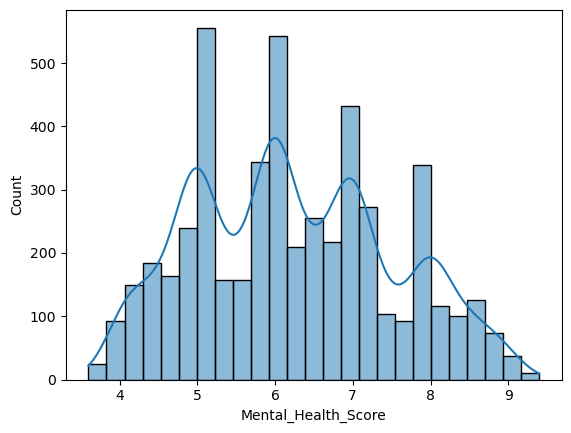

In [71]:
sns.histplot(data['Mental_Health_Score'],kde=True)

### 4.2 — Correlation heatmap

Which numeric features actually move together with the target?

<Axes: >

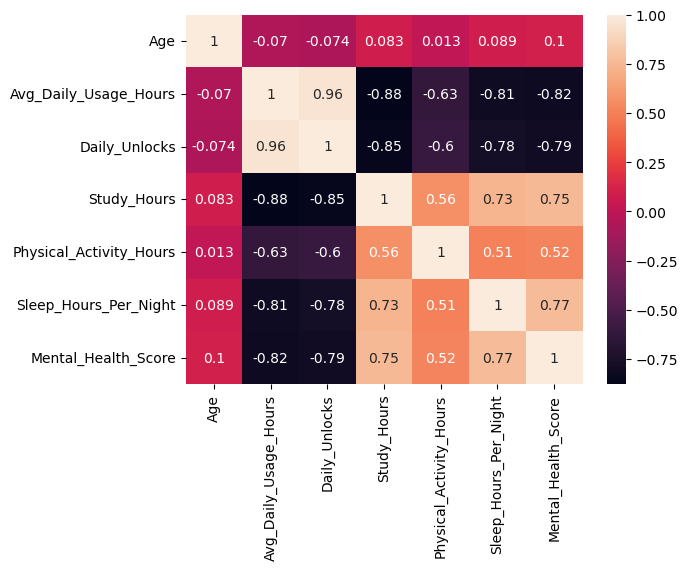

In [72]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

### 4.3 — Stress Level vs Mental Health Score

Does higher stress genuinely come with a lower score?

In [73]:
data['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [74]:
order=['Low', 'Medium', 'High', 'Very High']

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

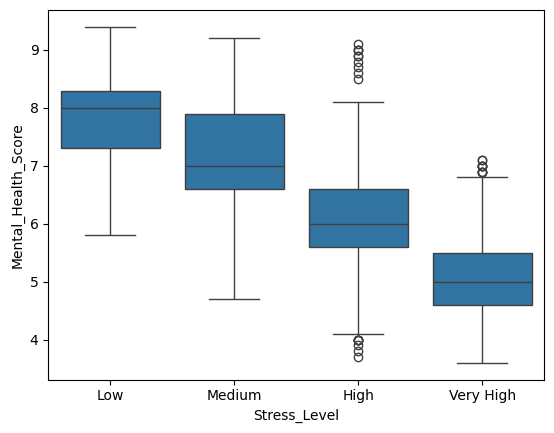

In [75]:
sns.boxplot(x='Stress_Level', y= 'Mental_Health_Score',data=data,order=order)

### 4.4 — Daily Usage Hours vs Mental Health Score

Does more time on social media relate to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

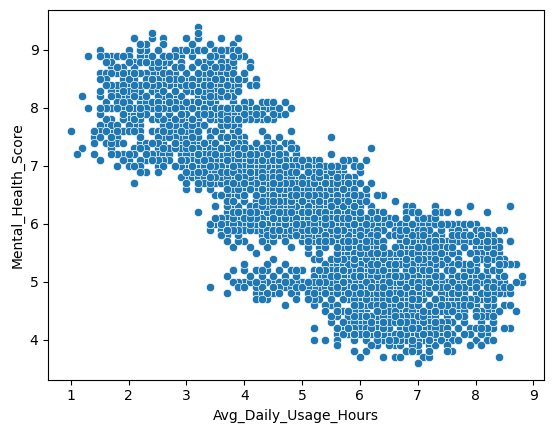

In [76]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',data=data)

### 4.5 — Sleep Hours vs Mental Health Score

Sleep is one of the most commonly cited mental health factors — does the data back that up?

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

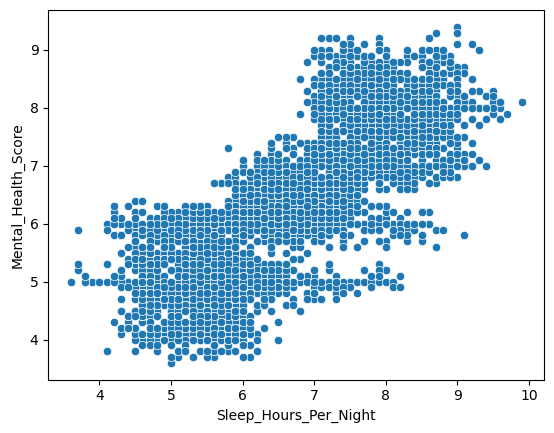

In [77]:
sns.scatterplot(x=data['Sleep_Hours_Per_Night'], y='Mental_Health_Score',data=data)

### 4.6 — Most Used Platform (count)

A quick look at which platforms are most common in our dataset.

In [78]:
platform_cnt= data['Most_Used_Platform'].value_counts()
platform_cnt

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

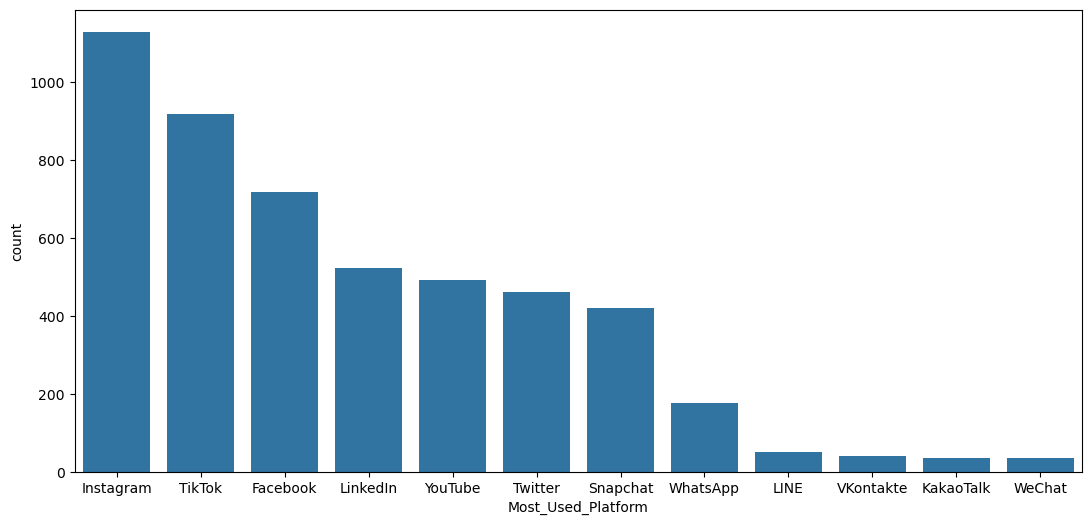

In [79]:
plt.figure(figsize=(13,6))
sns.countplot(x=data['Most_Used_Platform'],order=platform_cnt.index)

In [80]:
data.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

**Checking Outliers**

In [81]:
num_features= data.select_dtypes(include='number') #int64 or float64
num_features
Q1= num_features.quantile(0.25)
Q3= num_features.quantile(0.75) 
IQR= Q3-Q1

lower_bound= Q1 - 1.5*IQR
upper_bound= Q3 + 1.5*IQR

outliers= (num_features<lower_bound) | (num_features>upper_bound)
outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

## 5. Data Cleaning

Two real issues to fix here — everything else in this dataset is already clean, so we don't manufacture cleaning steps that aren't needed.

In [82]:
data.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [83]:
data.drop_duplicates()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [84]:
#ccoverting negative unrealistiv values to realistic values
data['Physical_Activity_Hours']=data['Physical_Activity_Hours'].clip(lower=0)

📌 **Why `clip(lower=0)` and not dropping the row:** the rest of that student's data (age, study hours, stress level, etc.) is still valid and useful — throwing away the whole row over one bad value wastes good data. Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.

We're not dropping any columns either — every column here has a plausible reason to matter for predicting mental health, and we already confirmed none of them are empty or constant.

## 6. Skewness

**What skewness is:** a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

`near to 0` -> Centralized
`negative` -> Left skewed
`positive` -> Right skewed

**Why it matters:** models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

Can be fixed using log transformation.

In [85]:
num_col= data.select_dtypes(include='number')
num_col.skew()

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.052632
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

## 7. Feature Engineering

**One meaningful engineered feature here:** grouping `Country`.

- `Country` has **111 unique values** in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
- Dropping `Country` entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
- **The fix:** keep the top 10 most frequent countries as their own category, and bucket everything else into `"Other"`. We keep the signal that matters and lose the noise that doesn't.

In [86]:
top_countries = data['Country'].value_counts().index[:10].to_list()

In [87]:
def group_countries(country):
  if country in top_countries:
      return country
  else:
      return 'Other' 
    

In [108]:
data['Country_Grouped'] = data['Country'].apply(group_countries)
data['Country_Grouped'].unique()

array(['Other', 'Canada', 'USA', 'India', 'Australia', 'UK', 'Germany',
       'France', 'Mexico', 'Turkey'], dtype=object)

In [89]:
data['Country_Grouped'].value_counts()

Country_Grouped
Other        3232
India         389
USA           355
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [112]:
data['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

📌 **Result:** we went from 111 raw categories down to 11 manageable ones (10 countries + "Other"). 

## 8. Encoding Strategy

Before we jump into code, let's decide *how* each categorical column should be encoded — this decision matters more than the code itself.

- **`Stress_Level` → Ordinal Encoding.** Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
- **`Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, `Country_Grouped` → One-Hot Encoding.** These categories have **no natural order** — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.

We'll implement both of these inside a single `ColumnTransformer` in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

In [90]:
data.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Country_Grouped
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


## 9. Train-Test Split

**Why we split:** we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

**Common ratios:** 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

We split **before** fitting any preprocessing — to avoid data leakage, and we'll avoid it by fitting everything only on the training set.

In [91]:
from sklearn.model_selection import train_test_split
skewed_col = ['Study_Hours']
other_numerical_col = ['Age','Avg_Daily_Usage_Hours','Sleep_Hours_Per_Night','Physical_Activity_Hours']
ordinal_col = ['Stress_Level']
nominal_col= ['Gender','Most_Used_Platform','Purpose_Of_Use','Country_Grouped','Academic_Level']

feature_col= skewed_col + other_numerical_col + ordinal_col + nominal_col
X= data[feature_col]
y= data['Mental_Health_Score']

X_train, X_test, y_train, y_test= train_test_split(X , y, test_size= 0.3, random_state= 42)

## 10. Preprocessing using ColumnTransformer

Our columns need **different treatment**:

- `Study_Hours` (the skewed one) → impute → `log1p` transform → scale
- The other numeric columns → impute → scale (no skew to fix)
- `Stress_Level` → impute → `OrdinalEncoder` with an **explicit order**
- The nominal columns → impute → `OneHotEncoder`

We include a `SimpleImputer` in every branch even though this dataset has zero missing values right now — it's a safety net. Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

`ColumnTransformer` glues all of this into **one object** that applies the right transformation to the right column type in a single `.fit()` / `.transform()` call — no manual column-by-column juggling.

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. Skew Pipeline
skew_pipeline= Pipeline(steps=[
  ('log_transform', FunctionTransformer(np.log1p)),
  ('scaler', StandardScaler())
])

#2. Numeric Pipeline
numeric_pipeline= Pipeline(steps=[
  ('scaler', StandardScaler())
])

#3. Ordinal Pipeline
ordinal_pipeline= Pipeline(steps=[
  ('ordinal_encoder', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Pipeline
nominal_pipeline= Pipeline(steps=[
  ('onehot_enocder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
  ('Skewed Pipeline', skew_pipeline, skewed_col),
  ('Numeric Pipeline', numeric_pipeline, other_numerical_col),
  ('Ordinal Pipeline', ordinal_pipeline, ordinal_col),
  ('Nominal Pipeline', nominal_pipeline, nominal_col)
])


## 11. Build a Pipeline

**Why Pipeline matters:** a `Pipeline` chains preprocessing and the model into a single object. Calling `.fit()` once does both steps in the correct order, and calling `.predict()` on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

**Why companies prefer this:** when this model gets deployed (which we're doing in Part 2 with FastAPI), the API doesn't need to know *anything* about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls `.predict()` on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model — so we can fairly compare them.

In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
lr_pipeline= Pipeline(steps=[
  ('preprocessor', preprocessor),
  ('regressor', LinearRegression())
])


## 12. Model Building

We're comparing **two models** here because the comparison itself teaches something useful — a plain Linear Regression baseline versus a Random Forest, which can capture the non-linear patterns we spotted back in EDA .


### 12.1 — Baseline: Linear Regression

In [94]:
lr_pipeline.fit(X_train, y_train)
lr_pred= lr_pipeline.predict(X_test)
lr_r2_testing = r2_score(y_test, lr_pred)
lr_r2_training= r2_score(y_train, lr_pipeline.predict(X_train))
print('R2 score for training data:', lr_r2_training)
print('R2 score for testing data:', lr_r2_testing)

lr_mae_testing= mean_absolute_error(y_test, lr_pred)

print('MAE score for testing data:', lr_mae_testing)

lr_mse_testing= mean_squared_error(y_test, lr_pred)

print('MSE score for testing data:', lr_mse_testing)

R2 score for training data: 0.7179141449610842
R2 score for testing data: 0.7528909660579312
MAE score for testing data: 0.5128459940764267
MSE score for testing data: 0.42708985985756986


### 12.2 — Random Forest (default settings)

Same preprocessor, different model at the end — that's the entire point of building the pipeline once.

In [95]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline= Pipeline(steps=[
  ('preprocessor', preprocessor),
  ('RandomForest regressor', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train,y_train)
rf_pred= rf_pipeline.predict(X_test)
rf_r2_testing= r2_score(y_test, rf_pred)
rf_r2_training= r2_score(y_train, rf_pipeline.predict(X_train))
print('R2 score for training data:', rf_r2_training)
print('R2 score for testing data:', rf_r2_testing)
#r2 -> accuracy
rf_mae_testing= mean_absolute_error(y_test, rf_pred)

print('MAE score for testing data:', rf_mae_testing)

rf_mse_testing= mean_squared_error(y_test, rf_pred)

print('MSE score for testing data:', rf_mse_testing)

R2 score for training data: 0.9796222187760245
R2 score for testing data: 0.8720559387069055
MAE score for testing data: 0.35247624444444453
MSE score for testing data: 0.22113158040222228


### 12.3 — Hyperparameter Tuning the Random Forest

When tuning a `Pipeline`, each parameter needs to be prefixed with the step name (`regressor__`) so `RandomizedSearchCV` knows which part of the pipeline it belongs to. We use `RandomizedSearchCV` instead of a full grid search — it samples a fixed number of combinations instead of testing every single one, which is far faster while still finding a strong set of parameters.

In [96]:
from sklearn.model_selection import RandomizedSearchCV


param_grid = {
  'RandomForest regressor__n_estimators': [100, 200, 300],
  'RandomForest regressor__max_depth': [5,10,15],
  'RandomForest regressor__min_samples_split': [2,5,10],
  'RandomForest regressor__min_samples_leaf': [1,2,4]
}

random_search = RandomizedSearchCV(
  estimator= rf_pipeline,
  param_distributions= param_grid,
  n_iter= 10,
  cv=5,
  scoring='r2',
  random_state=42,
  n_jobs=-1
)


In [97]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed '
                                                                               'Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Numeric '
                                                                               'Pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Sleep_Hours...
                                                                                'Country_Grouped',
                                                                                'Academic_Level'])])),
                                             ('RandomForest regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'RandomForest regressor__max_depth': [5,
                                                                              10,
                                                                              15],
                                        'RandomForest regressor__min_samples_leaf': [1,
                                                                                     2,
                                                                                     4],
                                        'RandomForest regressor__min_samples_split': [2,
                                                                                      5,
                                                                                      10],
                                        'RandomForest regressor__n_estimators': [100,
                                                                                 200,
                                                                                 300]},
                   random_state=42, scoring='r2')

In [98]:
random_search.best_params_

{'RandomForest regressor__n_estimators': 200,
 'RandomForest regressor__min_samples_split': 10,
 'RandomForest regressor__min_samples_leaf': 2,
 'RandomForest regressor__max_depth': 15}

In [99]:
rf_best_pipeline = random_search.best_estimator_
rf_best_pred= rf_best_pipeline.predict(X_test)
rf_best_r2_testing= r2_score(y_test, rf_best_pred)
print("R2 score for testing data after hyperparameter tuning:", rf_best_r2_testing)

rf_best_mae_testing= mean_absolute_error(y_test, rf_best_pred)
print("MAE score for testing data after hyperparameter tuning:", rf_best_mae_testing)

R2 score for testing data after hyperparameter tuning: 0.8535774558925902
MAE score for testing data after hyperparameter tuning: 0.38235435997068545


## 13. Model Evaluation

**Metrics, explained simply:**
- **R² Score** — how much of the variation in mental health scores our model explains, from 0 (useless) to 1 (perfect). 0.85 means the model explains 85% of the pattern.
- **MAE (Mean Absolute Error)** — on average, how far off our prediction is, in the original units (score points). Easy to explain to a non-technical person.
- **RMSE (Root Mean Squared Error)** — similar to MAE, but penalizes big mistakes more heavily. Useful for spotting whether a model makes a few very wrong predictions.

Cross-validation R² (from tuning, above) tells us how good the model is across many different train/validation splits — the real, honest test is still the untouched test set below.

In [100]:
lr_rmse= np.sqrt(mean_squared_error(y_test, lr_pred))

rf_rmse= np.sqrt(mean_squared_error(y_test, rf_pred))

#calculating RMSE for Random Forest after hyperparameter tuning
rf_best_rmse= np.sqrt(mean_squared_error(y_test, rf_best_pred))
rf_best_r2_training= r2_score(y_train, rf_best_pipeline.predict(X_train))
rf_best_mae= mean_absolute_error(y_test, rf_best_pred)

#creting a dataframe to compare the models

results = pd.DataFrame({
  'Models': ['Linear Regression', 'Random Forest', 'Random Forest (Tuned)'],
  'R2 Score': [lr_r2_testing, rf_r2_testing, rf_best_r2_testing],
  'Training R2': [lr_r2_training, rf_r2_training, rf_best_r2_training],
  'MAE': [lr_mae_testing, rf_mae_testing, rf_best_mae],
  'RMSE': [lr_rmse, rf_rmse, rf_best_rmse]
})
results

,Models,R2 Score,Training R2,MAE,RMSE
0,Linear Regression,0.752891,0.717914,0.512846,0.653521
1,Random Forest,0.872056,0.979622,0.352476,0.470246
2,Random Forest (Tuned),0.853577,0.928832,0.382354,0.503059


## 14. Save the Model

We save the **entire pipeline** — preprocessing and model together — as a single file, not just the raw model. **Why:** if we only saved the Random Forest object, our FastAPI backend would need to manually recreate every encoding and scaling step by hand at prediction time, which is fragile and easy to get wrong. Saving the full pipeline means the backend just loads one file and calls `.predict()` on raw input — the pipeline handles everything internally, exactly the same way it did during training.

In [101]:
import joblib
joblib.dump(rf_pipeline, 'mental_health_model.pkl')

['mental_health_model.pkl']

In [102]:
data.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Country_Grouped']